Raw data (first rows):
                measured_at  energy_consumption_kwh  temperature_celsius  \
0 2021-01-01 00:00:00+00:00              142.248994                 -0.3   
1 2021-01-01 01:00:00+00:00              133.500684                 -0.6   
2 2021-01-01 02:00:00+00:00              128.560861                 -0.2   
3 2021-01-01 03:00:00+00:00              127.513333                 -0.3   
4 2021-01-01 04:00:00+00:00              126.810857                 -0.3   
5 2021-01-01 05:00:00+00:00              121.279305                 -0.5   
6 2021-01-01 06:00:00+00:00              126.026241                 -0.5   
7 2021-01-01 07:00:00+00:00              133.067247                 -0.4   
8 2021-01-01 08:00:00+00:00              140.917220                 -0.7   
9 2021-01-01 09:00:00+00:00              147.253891                 -0.7   

   heating_demand  
0            18.3  
1            18.6  
2            18.2  
3            18.3  
4            18.3  
5            18.5  


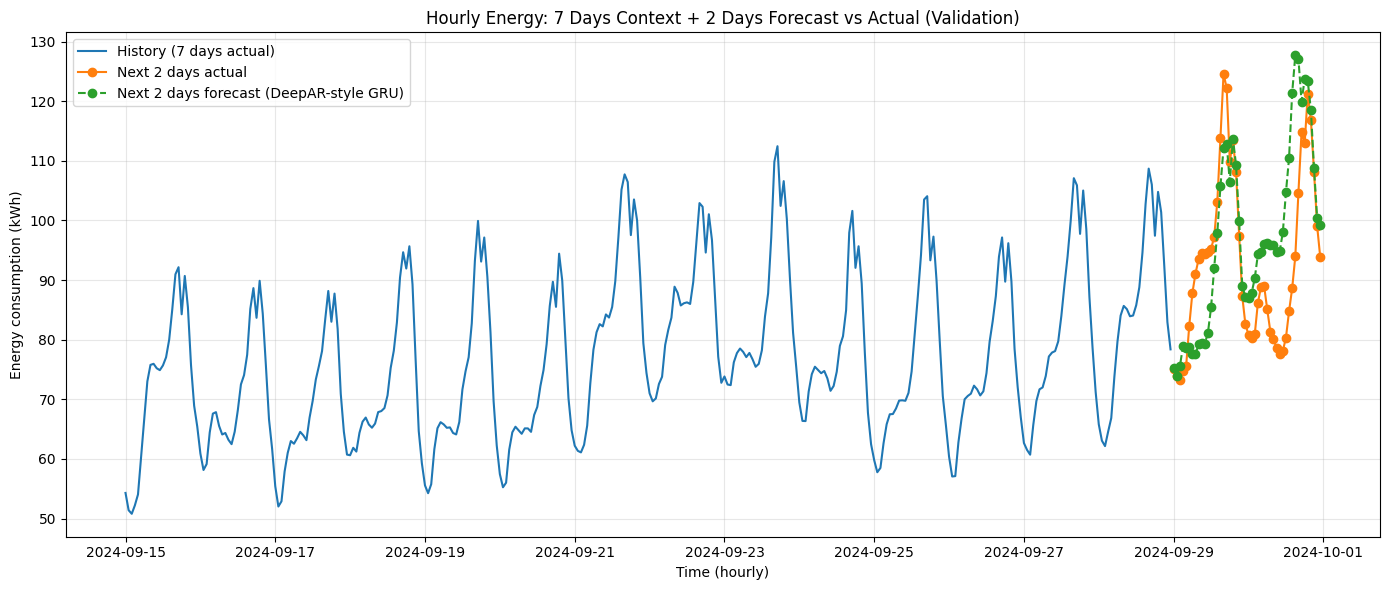

/tmp/ipython-input-2765668071.py:413: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  ts_future_infer = pd.date_range(


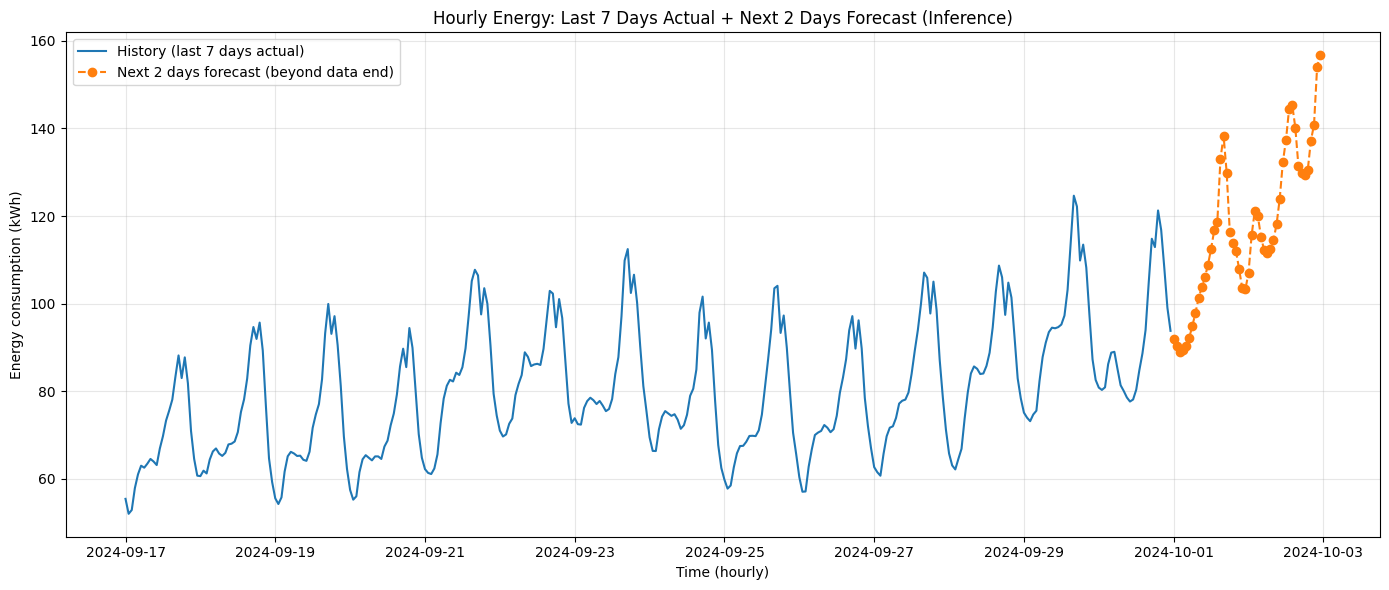

In [6]:
# ============================================================
# OPTIONAL: install deps (run once in a notebook cell/terminal)
# ============================================================
# !pip install torch pandas numpy matplotlib openpyxl

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ============================================================
# 1. CONFIG (HOURLY MODEL)
# ============================================================
FILE_PATH       = "20251111_JUNCTION_training.xlsx"
SHEET_NAME      = "training_data_2021_2024"   # hourly data as in your file
DATE_COL        = "measured_at"
TARGET_COL      = "energy_consumption_kwh"    # hourly total consumption
TEMP_COL        = "temperature_celsius"
DEMAND_COL      = "heating_demand"

# time setup in HOURS
HOURS_PER_DAY       = 24
CONTEXT_DAYS        = 14       # 7 days history
CONTEXT_LEN         = CONTEXT_DAYS * HOURS_PER_DAY  # 168 hours
VAL_FORECAST_DAYS   = 2            # predict 2 days ahead for validation
VAL_FORECAST_HOURS  = VAL_FORECAST_DAYS * HOURS_PER_DAY  # 48 hours

# same 2 days horizon for inference
INFER_FORECAST_DAYS  = 2
INFER_FORECAST_HOURS = INFER_FORECAST_DAYS * HOURS_PER_DAY

BATCH_SIZE      = 16
EPOCHS          = 250     # smaller than 400 so it trains in reasonable time
LR              = 1e-3
HIDDEN_SIZE     = 32
NUM_LAYERS      = 2

torch.manual_seed(0)
np.random.seed(0)


# ============================================================
# 2. LOAD DATA (HOURLY) & PREPARE INDICES
# ============================================================
df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

# ensure datetime and sort
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

print("Raw data (first rows):")
print(df[[DATE_COL, TARGET_COL, TEMP_COL, DEMAND_COL]].head(10))

n_hours = len(df)
print(f"\nTotal rows (hours) in data: {n_hours}")

# we reserve the last 7 days (context) + 2 days (forecast) as validation block
VAL_BLOCK_LEN = CONTEXT_LEN + VAL_FORECAST_HOURS

if n_hours <= VAL_BLOCK_LEN + CONTEXT_LEN:
    raise ValueError(
        f"Not enough data: need > {VAL_BLOCK_LEN + CONTEXT_LEN} hours, "
        f"but got {n_hours}."
    )

# train hours: everything before validation block
train_len = n_hours - VAL_BLOCK_LEN
print(f"Train hours: {train_len}")
print(f"Validation block hours (context+forecast): {VAL_BLOCK_LEN}")

train_start = 0
train_end   = train_len          # [0, train_len-1] used for training
val_start   = train_len          # start of validation block
val_end     = n_hours            # end of data

# In validation block:
#   - context: last 7 days of val block
#   - forecast: next 2 days of val block
val_context_start = val_start
val_context_end   = val_context_start + CONTEXT_LEN
val_forecast_start = val_context_end
val_forecast_end   = val_forecast_start + VAL_FORECAST_HOURS

print("\nTrain period :",
      df[DATE_COL].iloc[train_start],
      "->",
      df[DATE_COL].iloc[train_end - 1])
print("Val context :",
      df[DATE_COL].iloc[val_context_start],
      "->",
      df[DATE_COL].iloc[val_context_end - 1])
print("Val forecast:",
      df[DATE_COL].iloc[val_forecast_start],
      "->",
      df[DATE_COL].iloc[val_forecast_end - 1])


# ============================================================
# 3. NORMALIZATION (BASED ON TRAINING PERIOD)
# ============================================================
y_all    = df[TARGET_COL].values.astype(float)
temp_all = df[TEMP_COL].values.astype(float)
dem_all  = df[DEMAND_COL].values.astype(float)

y_train    = y_all[train_start:train_end]
temp_train = temp_all[train_start:train_end]
dem_train  = dem_all[train_start:train_end]

y_mean, y_std       = y_train.mean(), y_train.std() or 1.0
temp_mean, temp_std = temp_train.mean(), temp_train.std() or 1.0
dem_mean, dem_std   = dem_train.mean(), dem_train.std() or 1.0

y_norm    = (y_all - y_mean) / y_std
temp_norm = (temp_all - temp_mean) / temp_std
dem_norm  = (dem_all - dem_mean) / dem_std

print(f"\nTrain target mean: {y_mean:.3f}, std: {y_std:.3f}")


# ============================================================
# 4. BUILD TRAINING SEQUENCES (CONTEXT_LEN HOURS -> NEXT HOUR)
# ============================================================
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


X_train_list = []
y_train_list = []

# sliding windows over [train_start, train_end)
# each sample: context of CONTEXT_LEN hours, target = next hour
max_start = train_end - CONTEXT_LEN - 1  # target at start+CONTEXT_LEN
for start in range(train_start, max_start + 1):
    end = start + CONTEXT_LEN          # context: [start, ..., end-1]
    target_idx = end                   # predict hour at index `end`

    seq_y    = y_norm[start:end]
    seq_temp = temp_norm[start:end]
    seq_dem  = dem_norm[start:end]

    X_seq = np.stack([seq_y, seq_temp, seq_dem], axis=-1)   # (CONTEXT_LEN, 3)
    y_tgt = y_norm[target_idx]                              # scalar (normalized)

    X_train_list.append(X_seq)
    y_train_list.append(y_tgt)

X_train = np.stack(X_train_list, axis=0)  # (num_samples, CONTEXT_LEN, 3)
y_train = np.array(y_train_list)          # (num_samples,)

print(f"\nTraining samples: {X_train.shape[0]}, context length: {X_train.shape[1]}")

train_dataset = SeqDataset(X_train, y_train)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)


# ============================================================
# 5. DEFINE DEEPAR-STYLE MODEL (GRU + GAUSSIAN HEAD)
# ============================================================
class DeepARModel(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, num_layers=2):
        super().__init__()
        self.rnn = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc_mu    = nn.Linear(hidden_size, 1)
        self.fc_sigma = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.rnn(x)
        last_out = out[:, -1, :]                 # (batch, hidden_size)
        mu = self.fc_mu(last_out).squeeze(-1)    # (batch,)
        sigma = torch.nn.functional.softplus(
            self.fc_sigma(last_out)
        ).squeeze(-1) + 1e-6
        return mu, sigma


def gaussian_nll(y, mu, sigma):
    # Negative log-likelihood for Gaussian
    return 0.5 * torch.log(2 * math.pi * sigma**2) + (y - mu) ** 2 / (2 * sigma**2)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = DeepARModel(
    input_size=3,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)


# ============================================================
# 6. TRAINING LOOP
# ============================================================
model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        mu, sigma = model(X_batch)
        loss = gaussian_nll(y_batch, mu, sigma).mean()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * y_batch.size(0)

    epoch_loss /= len(train_dataset)
    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch}/{EPOCHS} - train NLL: {epoch_loss:.4f}")


# ============================================================
# 7. VALIDATION: 7 DAYS CONTEXT -> 2 DAYS FORECAST
# ============================================================
model.eval()

# build normalized exogenous block for validation
val_block_len = VAL_BLOCK_LEN  # CONTEXT_LEN + VAL_FORECAST_HOURS
val_temp_block = temp_norm[val_start:val_start + val_block_len]
val_dem_block  = dem_norm[val_start:val_start + val_block_len]

# y history for validation: first CONTEXT_LEN hours are real, rest will be predicted
y_hist_norm_val = np.zeros(val_block_len, dtype=float)
y_hist_norm_val[:CONTEXT_LEN] = y_norm[val_context_start:val_context_end]

pred_norm_val_list = []

with torch.no_grad():
    for t in range(CONTEXT_LEN, val_block_len):
        start = t - CONTEXT_LEN
        end   = t

        seq_y    = y_hist_norm_val[start:end]
        seq_temp = val_temp_block[start:end]
        seq_dem  = val_dem_block[start:end]

        X_seq = np.stack([seq_y, seq_temp, seq_dem], axis=-1)
        X_tensor = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(0).to(device)

        mu_pred, sigma_pred = model(X_tensor)
        y_pred_norm = mu_pred.cpu().numpy()[0]

        y_hist_norm_val[t] = y_pred_norm
        if t >= CONTEXT_LEN:
            pred_norm_val_list.append(y_pred_norm)

pred_norm_val_arr = np.array(pred_norm_val_list[-VAL_FORECAST_HOURS:])
y_pred_val_future = pred_norm_val_arr * y_std + y_mean  # denormalized

# ground truth for the validation forecast period (next 2 days)
y_true_val_future = y_all[val_forecast_start:val_forecast_end]
ts_context_val    = df[DATE_COL].values[val_context_start:val_context_end]
ts_future_val     = df[DATE_COL].values[val_forecast_start:val_forecast_end]


# ============================================================
# 8. METRICS & % ERRORS (VALIDATION 2 DAYS)
# ============================================================
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if not np.any(mask):
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100.0

def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    mask = denom != 0
    if not np.any(mask):
        return np.nan
    return np.mean(2.0 * np.abs(y_true[mask] - y_pred[mask]) / denom[mask]) * 100.0

mae_val   = np.mean(np.abs(y_true_val_future - y_pred_val_future))
mse_val   = np.mean((y_true_val_future - y_pred_val_future) ** 2)
rmse_val  = np.sqrt(mse_val)
mape_val  = safe_mape(y_true_val_future, y_pred_val_future)
smape_val = smape(y_true_val_future, y_pred_val_future)
rel_mae_pct_val = mae_val / np.mean(np.abs(y_true_val_future)) * 100.0

print("\n=== VALIDATION ERROR METRICS: next 2 days (48 hours) ===")
print(f"MAE          : {mae_val:.3f}")
print(f"MSE          : {mse_val:.3f}")
print(f"RMSE         : {rmse_val:.3f}")
print(f"MAPE         : {mape_val:.2f}%")
print(f"sMAPE        : {smape_val:.2f}%")
print(f"Relative MAE : {rel_mae_pct_val:.2f}% of average actual")


# ============================================================
# 9. PLOT: 7 DAYS ACTUAL + 2 DAYS PREDICTED VS ACTUAL (VALIDATION)
# ============================================================
plt.figure(figsize=(14, 6))

# 7 days of context (actual)
plt.plot(
    ts_context_val,
    y_all[val_context_start:val_context_end],
    label="History (7 days actual)",
)

# 2 days actual
plt.plot(
    ts_future_val,
    y_true_val_future,
    marker="o",
    label="Next 2 days actual",
)

# 2 days prediction
plt.plot(
    ts_future_val,
    y_pred_val_future,
    marker="o",
    linestyle="--",
    label="Next 2 days forecast (DeepAR-style GRU)",
)

plt.title("Hourly Energy: 7 Days Context + 2 Days Forecast vs Actual (Validation)")
plt.xlabel("Time (hourly)")
plt.ylabel("Energy consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 10. INFERENCE: 2 DAYS AFTER END OF DATA
#      - last 7 days as context
#      - simple exogenous extrapolation: repeat last 24h pattern
# ============================================================
infer_context_len   = CONTEXT_LEN
infer_forecast_len  = INFER_FORECAST_HOURS
infer_block_len     = infer_context_len + infer_forecast_len

# context = last 7 days of data
infer_context_start = n_hours - infer_context_len
infer_context_end   = n_hours

y_context_norm_infer    = y_norm[infer_context_start:infer_context_end]
temp_context_norm_infer = temp_norm[infer_context_start:infer_context_end]
dem_context_norm_infer  = dem_norm[infer_context_start:infer_context_end]

# build exog block: context + repeated daily pattern for future
temp_block_infer = np.zeros(infer_block_len, dtype=float)
dem_block_infer  = np.zeros(infer_block_len, dtype=float)

temp_block_infer[:infer_context_len] = temp_context_norm_infer
dem_block_infer[:infer_context_len]  = dem_context_norm_infer

for t in range(infer_context_len, infer_block_len):
    # repeat last 24 hours pattern for exogenous variables
    source_idx = t - HOURS_PER_DAY
    if source_idx < 0:
        source_idx = t - 1
    temp_block_infer[t] = temp_block_infer[source_idx]
    dem_block_infer[t]  = dem_block_infer[source_idx]

# y history for inference
y_hist_norm_infer = np.zeros(infer_block_len, dtype=float)
y_hist_norm_infer[:infer_context_len] = y_context_norm_infer

pred_norm_infer_list = []

with torch.no_grad():
    for t in range(infer_context_len, infer_block_len):
        start = t - infer_context_len
        end   = t

        seq_y    = y_hist_norm_infer[start:end]
        seq_temp = temp_block_infer[start:end]
        seq_dem  = dem_block_infer[start:end]

        X_seq = np.stack([seq_y, seq_temp, seq_dem], axis=-1)
        X_tensor = torch.tensor(X_seq, dtype=torch.float32).unsqueeze(0).to(device)

        mu_pred, sigma_pred = model(X_tensor)
        y_pred_norm = mu_pred.cpu().numpy()[0]

        y_hist_norm_infer[t] = y_pred_norm
        pred_norm_infer_list.append(y_pred_norm)

pred_norm_infer_arr = np.array(pred_norm_infer_list[-infer_forecast_len:])
y_pred_infer_future = pred_norm_infer_arr * y_std + y_mean  # denormalized

# timestamps: last 7 days context + 2 days future
ts_context_infer = df[DATE_COL].values[infer_context_start:infer_context_end]
last_ts = df[DATE_COL].iloc[-1]
ts_future_infer = pd.date_range(
    start=last_ts + pd.Timedelta(hours=1),
    periods=infer_forecast_len,
    freq="H"
)


# ============================================================
# 11. PLOT: LAST 7 DAYS + 2 DAYS FORECAST (AFTER DATA END)
# ============================================================
plt.figure(figsize=(14, 6))

# last 7 days actual
plt.plot(
    ts_context_infer,
    y_all[infer_context_start:infer_context_end],
    label="History (last 7 days actual)",
)

# 2 days forecast after end of data
plt.plot(
    ts_future_infer,
    y_pred_infer_future,
    marker="o",
    linestyle="--",
    label="Next 2 days forecast (beyond data end)",
)

plt.title("Hourly Energy: Last 7 Days Actual + Next 2 Days Forecast (Inference)")
plt.xlabel("Time (hourly)")
plt.ylabel("Energy consumption (kWh)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
